# QS World Ranking — MLP (Neural Network) Classification

**Goal.** Classify each institution directly into a performance tier — **Low**, **Medium** or **High** — using a Multi-Layer Perceptron classifier (`MLPClassifier`), following the same method used for the SVM notebook.

The target `score_category` is derived from `overall_score`, grouped into three tiers:

| Tier | Overall Score range |
|------|--------------------|
| Low | 11 – 18 |
| Medium | 19 – 28 |
| High | 29 – 100 |

**Method — MLP classification with hyperparameter tuning.** The network predicts the tier label directly. `GridSearchCV` searches over the key neural-network hyperparameters:

- **hidden_layer_sizes** — network architecture with **three hidden layers**: `(100, 50, 25)` and `(128, 64, 32)`
- **activation** — `relu` and `tanh`
- **alpha** — the **L2 regularisation penalty** (`0.0001, 0.01`)
- **learning_rate_init** — the **learning rate** for the Adam optimiser (`0.001, 0.01`)

> Naming note: in scikit-learn's `MLPClassifier`, `alpha` is the L2 weight-decay penalty (regularisation), **not** the learning rate. The learning rate is `learning_rate_init`. Both are tuned here. The solver is fixed to `adam`, with `max_iter=300` and loss-based stopping (`n_iter_no_change`). Over-fitting is monitored directly via the training-vs-validation loss curves in Section 8.

**Two feature sets** are tuned and evaluated separately:

- **Without ranks** — the eight QS component *scores* plus institutional attributes.
- **With ranks** — the same, plus the eight QS component *rank* columns.

Each is tuned by grid search on a training split, evaluated on a hold-out test set, and cross-validated (10-fold) for stability.

> Leakage note: `overall_score` defines the target and is never a feature. The overall QS `rank` / `rank_numeric` is a direct ordering of `overall_score`, so it too is excluded. Only the eight *component* rank columns are added in the "with ranks" set. Features are standardised, which neural networks require.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, log_loss,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42

## 1. Load the cleaned data

In [2]:
df = pd.read_excel("QS_world_ranking.xlsx", sheet_name="Cleaned_Data")

df = df.loc[:, ~df.columns.str.startswith("Unnamed")]
df.columns = df.columns.str.strip()   # e.g. 'Public ' -> 'Public'

print("Shape:", df.shape)
df.head()

Shape: (7431, 29)


,year,institution,country,academic_reputation_rank,academic_reputation_score,citations_per_faculty_rank,citations_per_faculty_score,employer_reputation_rank,employer_reputation_score,employment_outcomes_rank,employment_outcomes_score,faculty_student_ratio_rank,faculty_student_ratio_score,international_faculty_ratio_rank,international_faculty_ratio_score,international_research_network_rank,international_research_network_score,international_students_ratio_rank,international_students_ratio_score,research,size,rank_numeric,size_ordinal,research_ordinal,Private,Public,score_category,overall_score,rank
0,2023,Massachusetts Institute of Technology (MIT),United States,5,100.0,5,100.0,4,100.0,3,100.0,14,100.0,54,100.0,58,96.1,109,90.0,VH,M,1.0,2,4,1,0,High,100.0,1
1,2023,University of Cambridge,United Kingdom,2,100.0,55,92.3,2,100.0,9,100.0,11,100.0,60,100.0,6,99.5,70,96.3,VH,L,2.0,3,4,0,1,High,98.8,2
2,2023,Stanford University,United States,4,100.0,9,99.9,5,100.0,2,100.0,6,100.0,74,99.8,55,96.3,235,60.3,VH,L,3.0,3,4,1,0,High,98.5,3
3,2023,University of Oxford,United Kingdom,3,100.0,64,90.0,3,100.0,7,100.0,8,100.0,101,98.8,3,99.9,54,98.4,VH,L,4.0,3,4,0,1,High,98.4,4
4,2023,Harvard University,United States,1,100.0,2,100.0,1,100.0,1,100.0,35,99.4,228,76.9,1,100.0,212,66.9,VH,L,5.0,3,4,1,0,High,97.6,5


## 2. Target variable — the three performance tiers

score_category
Low       2612
High      2466
Medium    2353
Name: count, dtype: int64


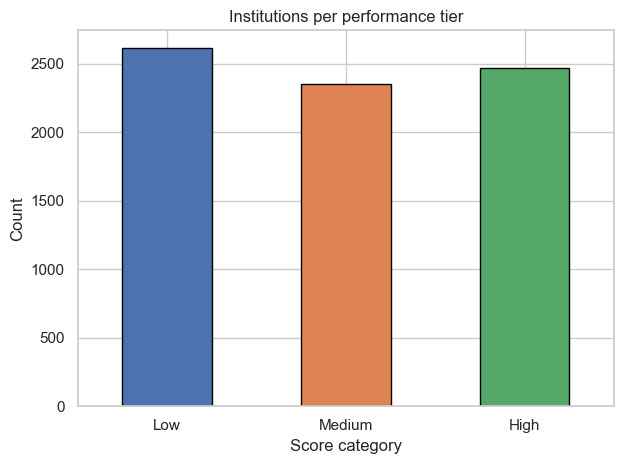

In [3]:
print(df["score_category"].value_counts())

ax = df["score_category"].value_counts().reindex(["Low", "Medium", "High"]).plot(
    kind="bar", color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black"
)
ax.set_title("Institutions per performance tier")
ax.set_xlabel("Score category")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [4]:
tier_ranges = (
    df.groupby("score_category")["overall_score"]
      .agg(["min", "max", "count"])
      .reindex(["Low", "Medium", "High"])
)
print(tier_ranges)

                      min         max  count
score_category                              
Low             11.418222   18.035674   2612
Medium          18.997531   28.300000   2353
High            28.329192  100.000000   2466


## 3. Clean the component rank columns

The eight `*_rank` columns are stored as text and contain banded values such as `501+`, `601+`. We strip the `+` and convert to a numeric rank so they can be used as features.

In [5]:
rank_cols = [
    "academic_reputation_rank",
    "citations_per_faculty_rank",
    "employer_reputation_rank",
    "employment_outcomes_rank",
    "faculty_student_ratio_rank",
    "international_faculty_ratio_rank",
    "international_research_network_rank",
    "international_students_ratio_rank",
]

for c in rank_cols:
    df[c] = (
        df[c].astype(str)
             .str.replace("+", "", regex=False)
             .str.strip()
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[rank_cols] = df[rank_cols].fillna(df[rank_cols].max())
print(df[rank_cols].describe().T[["min", "max", "mean"]].round(1))

                                     min     max   mean
academic_reputation_rank             1.0   701.0  490.9
citations_per_faculty_rank           1.0   934.0  545.7
employer_reputation_rank             1.0   778.0  491.1
employment_outcomes_rank             1.0  1012.0  547.9
faculty_student_ratio_rank           1.0   801.0  547.7
international_faculty_ratio_rank     1.0  1198.0  546.4
international_research_network_rank  1.0  1239.0  546.4
international_students_ratio_rank    1.0  1148.0  545.4


## 4. Feature sets and the classification target

In [6]:
score_features = [
    "academic_reputation_score",
    "citations_per_faculty_score",
    "employer_reputation_score",
    "employment_outcomes_score",
    "faculty_student_ratio_score",
    "international_faculty_ratio_score",
    "international_students_ratio_score",
    "international_research_network_score",
]
attribute_features = ["size_ordinal", "research_ordinal", "Private", "Public"]

feature_sets = {
    "Without ranks": score_features + attribute_features,
    "With ranks":    score_features + attribute_features + rank_cols,
}
for name, feats in feature_sets.items():
    print(f"{name:14s}: {len(feats)} features")

# Classification target (the tier label) — the MLP predicts this directly
y = df["score_category"]
tier_order = ["Low", "Medium", "High"]

Without ranks : 12 features
With ranks    : 20 features


## 5. Hyperparameter tuning with GridSearchCV

For each feature set we split 75/25 (stratified), then run a 3-fold grid search over `hidden_layer_sizes`, `activation`, `alpha` (L2 penalty) and `learning_rate_init` (learning rate) on the training data. A 3-fold search keeps the 16-configuration grid fast; the final model is validated with 10-fold CV later.

In [8]:
param_grid = {
    "mlpclassifier__hidden_layer_sizes": [(25), (25,50),(128, 64, 32)],
    "mlpclassifier__activation": ["relu"],
    "mlpclassifier__alpha": [1e-4, 1e-2],
    "mlpclassifier__learning_rate_init": [1e-3, 1e-2],
}

# Note: early_stopping is left False. In scikit-learn 1.6.x, early_stopping=True
# with string class labels raises a TypeError (np.isnan on string predictions).
# Convergence is instead controlled by max_iter and n_iter_no_change (loss-based),
# and over-fitting is monitored via the training-vs-validation loss curves below.
base_mlp = MLPClassifier(solver="adam", max_iter=100, early_stopping=False,
                         n_iter_no_change=15, tol=1e-4, random_state=RANDOM_STATE)

searches = {}   # feature set -> fitted GridSearchCV
splits   = {}   # feature set -> (X_train, X_test, y_train, y_test)

for set_name, feats in feature_sets.items():
    X = df[feats]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
    )
    pipe = make_pipeline(StandardScaler(), base_mlp)
    gs = GridSearchCV(pipe, param_grid, cv=3, scoring="accuracy", n_jobs=1)
    gs.fit(X_tr, y_tr)
    searches[set_name] = gs
    splits[set_name] = (X_tr, X_te, y_tr, y_te)
    best = {k.replace("mlpclassifier__", ""): v for k, v in gs.best_params_.items()}
    print(f"{set_name:14s} -> best {best}")
    print(f"{'':14s}    best CV acc = {gs.best_score_:.4f}")

Without ranks  -> best {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': 25, 'learning_rate_init': 0.001}
                  best CV acc = 0.8678
With ranks     -> best {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (25, 50), 'learning_rate_init': 0.001}
                  best CV acc = 0.9289


## 6. Hold-out evaluation of the tuned models

In [9]:
for set_name, gs in searches.items():
    X_tr, X_te, y_tr, y_te = splits[set_name]
    y_pred = gs.predict(X_te)
    print(f"===== {set_name} =====")
    print(f"Test accuracy: {accuracy_score(y_te, y_pred):.4f}\n")
    print(classification_report(y_te, y_pred, digits=3))
    print()

===== Without ranks =====
Test accuracy: 0.8794

              precision    recall  f1-score   support

        High      0.964     0.958     0.961       617
         Low      0.871     0.858     0.864       653
      Medium      0.802     0.821     0.812       588

    accuracy                          0.879      1858
   macro avg      0.879     0.879     0.879      1858
weighted avg      0.880     0.879     0.880      1858


===== With ranks =====
Test accuracy: 0.9494

              precision    recall  f1-score   support

        High      0.974     0.968     0.971       617
         Low      0.954     0.957     0.956       653
      Medium      0.919     0.922     0.920       588

    accuracy                          0.949      1858
   macro avg      0.949     0.949     0.949      1858
weighted avg      0.949     0.949     0.949      1858




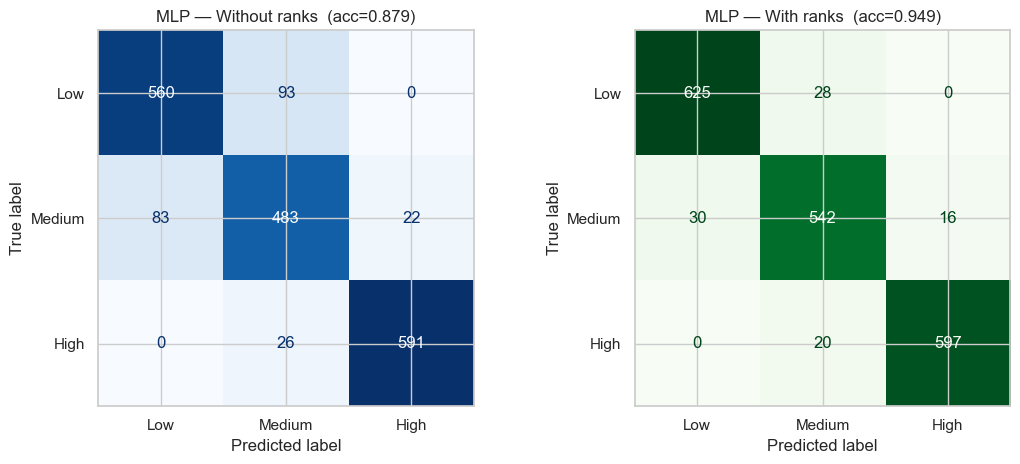

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, (set_name, gs), cmap in zip(axes, searches.items(), ["Blues", "Greens"]):
    X_tr, X_te, y_tr, y_te = splits[set_name]
    y_pred = gs.predict(X_te)
    cm = confusion_matrix(y_te, y_pred, labels=tier_order)
    ConfusionMatrixDisplay(cm, display_labels=tier_order).plot(
        cmap=cmap, ax=ax, colorbar=False, values_format="d")
    ax.set_title(f"MLP — {set_name}  (acc={accuracy_score(y_te, y_pred):.3f})")
plt.tight_layout()
plt.show()

## 7. Visualising the grid search

Heatmaps of mean cross-validated accuracy over the `alpha` × `learning_rate_init` grid, filtered to the best architecture and the `relu` activation — showing how regularisation and learning rate interact.

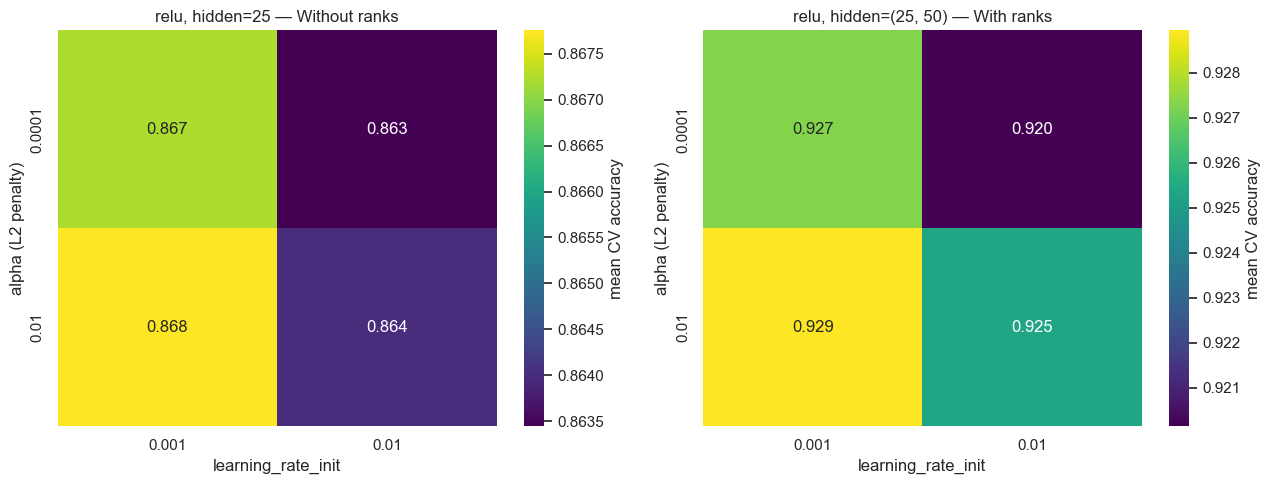

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (set_name, gs) in zip(axes, searches.items()):
    res = pd.DataFrame(gs.cv_results_)
    best_hls = gs.best_params_["mlpclassifier__hidden_layer_sizes"]
    sub = res[(res["param_mlpclassifier__activation"] == "relu") &
              (res["param_mlpclassifier__hidden_layer_sizes"] == best_hls)].copy()
    pivot = sub.pivot_table(index="param_mlpclassifier__alpha",
                            columns="param_mlpclassifier__learning_rate_init",
                            values="mean_test_score")
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax,
                cbar_kws={"label": "mean CV accuracy"})
    ax.set_title(f"relu, hidden={best_hls} — {set_name}")
    ax.set_xlabel("learning_rate_init")
    ax.set_ylabel("alpha (L2 penalty)")
plt.tight_layout()
plt.show()

## 8. Training vs validation loss per epoch

For each feature set the best tuned network is retrained epoch by epoch with `partial_fit`, tracking the log-loss on both the training set and a held-out validation set. Training loss that keeps falling while validation loss turns upward is the classic sign of over-fitting; the dashed line marks the epoch of lowest validation loss (best generalisation).

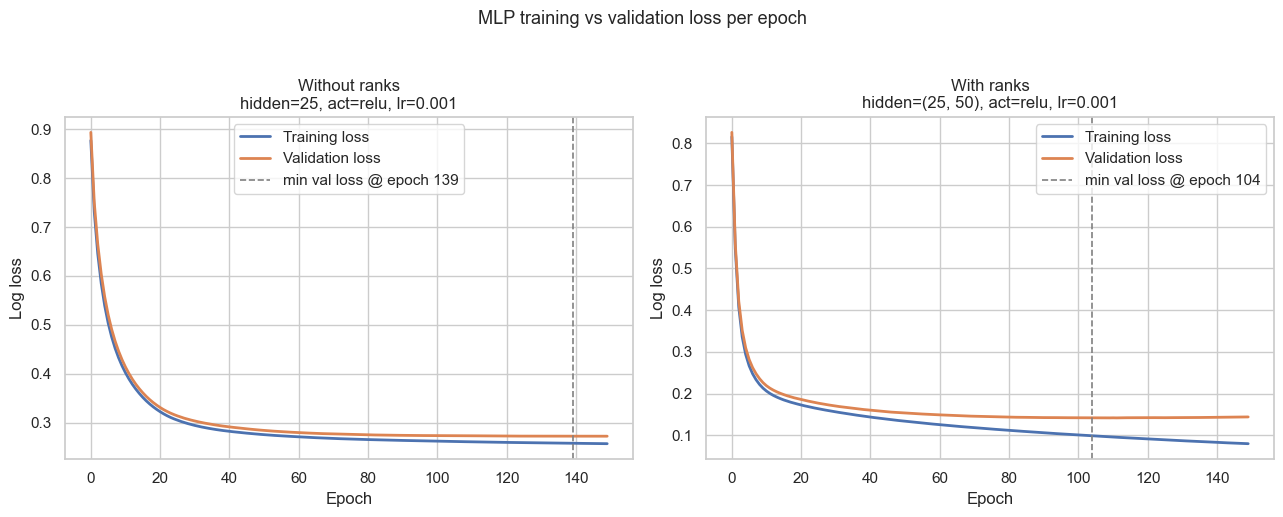

In [13]:
def epoch_loss_curves(feats, params, n_epochs=150, val_size=0.2):
    """Train the given MLP config epoch-by-epoch; return (train_loss, val_loss)."""
    X = df[feats]
    X_tr, X_val, y_tr, y_val = train_test_split(
        X, y, test_size=val_size, random_state=RANDOM_STATE, stratify=y)
    scaler = StandardScaler().fit(X_tr)
    Xtr, Xval = scaler.transform(X_tr), scaler.transform(X_val)

    mlp = MLPClassifier(solver="adam", random_state=RANDOM_STATE, **params)
    classes = np.unique(y)
    tr_loss, va_loss = [], []
    for _ in range(n_epochs):
        mlp.partial_fit(Xtr, y_tr, classes=classes)   # one epoch, keeps optimiser state
        tr_loss.append(log_loss(y_tr, mlp.predict_proba(Xtr), labels=classes))
        va_loss.append(log_loss(y_val, mlp.predict_proba(Xval), labels=classes))
    return tr_loss, va_loss

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, set_name in zip(axes, feature_sets):
    params = {k.replace("mlpclassifier__", ""): v
              for k, v in searches[set_name].best_params_.items()}
    tr_loss, va_loss = epoch_loss_curves(feature_sets[set_name], params)
    ax.plot(tr_loss, color="#4C72B0", lw=2, label="Training loss")
    ax.plot(va_loss, color="#DD8452", lw=2, label="Validation loss")
    best_ep = int(np.argmin(va_loss))
    ax.axvline(best_ep, color="grey", ls="--", lw=1.2,
               label=f"min val loss @ epoch {best_ep}")
    ax.set_title(f"{set_name}\nhidden={params['hidden_layer_sizes']}, "
                 f"act={params['activation']}, lr={params['learning_rate_init']}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Log loss")
    ax.legend()
fig.suptitle("MLP training vs validation loss per epoch", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

## 9. 10-fold cross-validation of the tuned models

Using the best hyperparameters found for each feature set, we run 10-fold stratified cross-validation on the full dataset.

In [14]:
cv_scores = {}
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
for set_name, feats in feature_sets.items():
    X = df[feats]
    cv_scores[set_name] = cross_val_score(
        searches[set_name].best_estimator_, X, y, cv=skf,
        scoring="accuracy", n_jobs=1,
    )
    arr = cv_scores[set_name]
    print(f"{set_name:14s}: mean={arr.mean():.4f}  std={arr.std():.4f}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}")

Without ranks : mean=0.8742  std=0.0087  min=0.8654  max=0.8910
With ranks    : mean=0.9363  std=0.0116  min=0.9219  max=0.9570


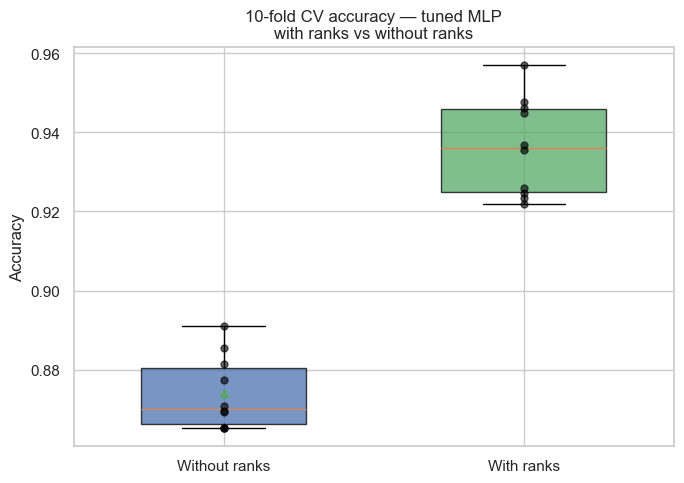

In [15]:
colours = ["#4C72B0", "#55A868"]
fig, ax = plt.subplots(figsize=(7, 5))
data = [cv_scores["Without ranks"], cv_scores["With ranks"]]
bp = ax.boxplot(data, labels=["Without ranks", "With ranks"],
                patch_artist=True, widths=0.55, showmeans=True)
for patch, col in zip(bp["boxes"], colours):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
for i, d in enumerate(data, start=1):
    ax.scatter(np.full_like(d, i, dtype=float), d, color="black", alpha=0.6, zorder=3, s=25)
ax.set_title("10-fold CV accuracy — tuned MLP\nwith ranks vs without ranks")
ax.set_ylabel("Accuracy")
plt.tight_layout()
plt.show()

## 10. Comparison — with ranks vs without ranks

               Best CV (grid search)  Test accuracy  10-fold CV mean
Feature set                                                         
Without ranks                 0.8678         0.8794           0.8742
With ranks                    0.9289         0.9494           0.9363


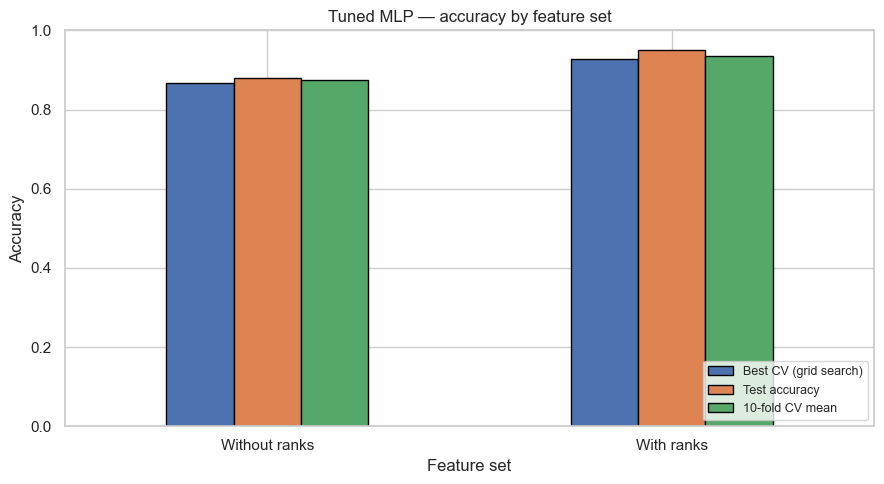

In [20]:
summary = pd.DataFrame({
    "Feature set": ["Without ranks", "With ranks"],
    "Best CV (grid search)": [searches["Without ranks"].best_score_,
                              searches["With ranks"].best_score_],
    "Test accuracy": [
        accuracy_score(splits["Without ranks"][3],
                       searches["Without ranks"].predict(splits["Without ranks"][1])),
        accuracy_score(splits["With ranks"][3],
                       searches["With ranks"].predict(splits["With ranks"][1])),
    ],
    "10-fold CV mean": [cv_scores["Without ranks"].mean(),
                        cv_scores["With ranks"].mean()],
}).set_index("Feature set")
print(summary.round(4))

ax = summary.plot(kind="bar", figsize=(9, 5),
                  color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="black")
ax.set_title("Tuned MLP — accuracy by feature set")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 11. Visualising the MLP decision boundary

For intuition we fit an MLP on the two most predictive score features and shade the tier it assigns to each region, with the data points overlaid.

Decision boundary on top-2 predictors: academic_reputation_score  &  employer_reputation_score


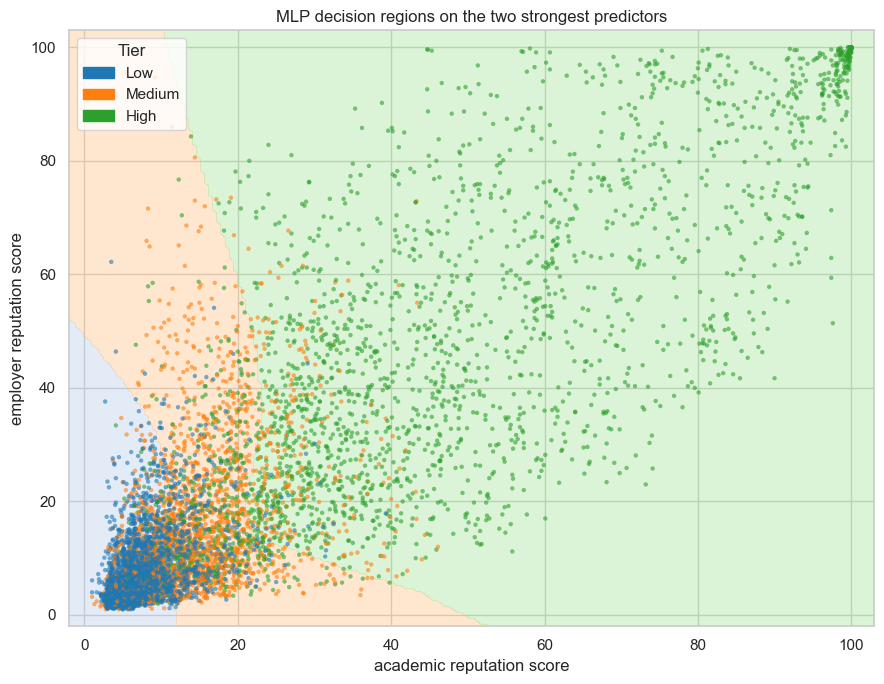

In [21]:
corrs = df[score_features].corrwith(df["overall_score"]).abs().sort_values(ascending=False)
f1, f2 = corrs.index[0], corrs.index[1]
print(f"Decision boundary on top-2 predictors: {f1}  &  {f2}")

X2 = df[[f1, f2]].values
clf2 = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(25, 50), activation="relu", solver="adam",
                  alpha=1e-3, learning_rate_init=1e-3, max_iter=500,
                  random_state=RANDOM_STATE),
)
clf2.fit(X2, y)

pad1 = 0.03 * (X2[:, 0].max() - X2[:, 0].min())
pad2 = 0.03 * (X2[:, 1].max() - X2[:, 1].min())
g1 = np.linspace(X2[:, 0].min() - pad1, X2[:, 0].max() + pad1, 200)
g2 = np.linspace(X2[:, 1].min() - pad2, X2[:, 1].max() + pad2, 200)
G1, G2 = np.meshgrid(g1, g2)
grid = np.column_stack([G1.ravel(), G2.ravel()])

Z = pd.Categorical(clf2.predict(grid), categories=tier_order).codes.reshape(G1.shape)
y_code = pd.Categorical(y, categories=tier_order).codes

region_cmap = ListedColormap(["#AEC7E8", "#FFBB78", "#98DF8A"])
point_cmap  = ListedColormap(["#1F77B4", "#FF7F0E", "#2CA02C"])

fig, ax = plt.subplots(figsize=(9, 7))
ax.contourf(G1, G2, Z, alpha=0.35, cmap=region_cmap, levels=[-0.5, 0.5, 1.5, 2.5])
ax.scatter(X2[:, 0], X2[:, 1], c=y_code, cmap=point_cmap, s=10, alpha=0.6,
           edgecolor="none")
ax.set_xlabel(f1.replace("_", " "))
ax.set_ylabel(f2.replace("_", " "))
ax.set_title("MLP decision regions on the two strongest predictors")
handles = [mpatches.Patch(color=point_cmap(i), label=t) for i, t in enumerate(tier_order)]
ax.legend(handles=handles, title="Tier", loc="upper left")
plt.tight_layout()
plt.show()

## 12. Summary

In [22]:
best_overall = summary["10-fold CV mean"].idxmax()
print("Best hyperparameters found:\n")
for set_name, gs in searches.items():
    best = {k.replace("mlpclassifier__", ""): v for k, v in gs.best_params_.items()}
    print(f"  {set_name:14s}: {best}")
print("\nAccuracy summary:\n")
print(summary.round(4))
print(f"\nBest feature set by 10-fold CV: {best_overall}")

Best hyperparameters found:

  Without ranks : {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': 25, 'learning_rate_init': 0.001}
  With ranks    : {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (25, 50), 'learning_rate_init': 0.001}

Accuracy summary:

               Best CV (grid search)  Test accuracy  10-fold CV mean
Feature set                                                         
Without ranks                 0.8678         0.8794           0.8742
With ranks                    0.9289         0.9494           0.9363

Best feature set by 10-fold CV: With ranks


### Findings

- **Method.** The MLP (a feed-forward neural network) classifies the tier `score_category` directly, mirroring the SVM notebook. `GridSearchCV` tuned architecture, activation, the L2 penalty `alpha` and the learning rate `learning_rate_init`.
- **Hyperparameters.** `alpha` controls weight decay (regularisation); `learning_rate_init` controls the Adam step size — the two are distinct and both were searched. The grid-search heatmaps show how they trade off.
- **With vs without ranks.** Adding the eight component rank columns raises accuracy and tightens the fold-to-fold spread (grouped bar and boxplot).
- **Convergence & over-fitting.** The training-vs-validation loss curves reveal generalisation directly: the dashed line marks the epoch of lowest validation loss. A widening gap after that point would indicate over-fitting, which the `alpha` (L2) penalty guards against.
- Most residual errors sit between neighbouring tiers (Low↔Medium, Medium↔High), expected since the tiers are contiguous bands of one underlying score.